Практическое задание «Модели авторегрессии условной гетероскедантичности»

Информация для студентов
Примерное время выполнения задания - 90 минут
Выполнив это задание, вы:
Отработаете навык построения модели GARCH для временного ряда и оформление отчета в Jupyter-ноутбуке

Инструменты и материалы, которые пригодятся для выполнения задания

    machinelearningmastery.com...in-python/
    www.youtube.com...ritvikmath
    www.youtube.com...ritvikmath

Задание

Выберите один из рядов в материалах к заданию и постройте для него модель Garch, также сделайте вывод по полученным результатам.

Инструкция к выполнению

    Выберите любой из рядов для работы (можно поэкспериментировать с несколькими рядами)
    Аналогично лекционному ноутбуку подберите оптимальные параметры ARIMA для ряда
    Используя найденные параметры, постройте модель Garch этого ряда
    Не забудьте, что Garch работает только со стационарными рядами (!)
    Сделайте выводы по полученным результатам, насколько хорошо Garch подходит для выбранного ряда


In [1]:
import pandas as pd
import numpy as np
import tqdm
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import matplotlib.pyplot as plt

from math import sqrt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
%matplotlib inline

In [3]:
def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)


def tsplot(y, lags=None, figsize=(14, 8), style='bmh'):
    test_stationarity(y)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (5, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0))
        pacf_ax = plt.subplot2grid(layout, (3, 0))
        qq_ax = plt.subplot2grid(layout, (4, 0))

        y.plot(ax=ts_ax, color='blue', label='Or')
        ts_ax.set_title('Original')

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05)
        sm.qqplot(y, line='s', ax=qq_ax)
        
        plt.tight_layout()
    return

In [4]:
file_path = '/home/slava/Documents/netology_ML/Временные ряды/материалы/data_sets/Series/daily-total-female-births-in-cal.csv'
series = pd.read_csv(file_path).dropna().values[:, 1].astype(float)
print(series)

[35. 32. 30. 31. 44. 29. 45. 43. 38. 27. 38. 33. 55. 47. 45. 37. 50. 43.
 41. 52. 34. 53. 39. 32. 37. 43. 39. 35. 44. 38. 24. 23. 31. 44. 38. 50.
 38. 51. 31. 31. 51. 36. 45. 51. 34. 52. 47. 45. 46. 39. 48. 37. 35. 52.
 42. 45. 39. 37. 30. 35. 28. 45. 34. 36. 50. 44. 39. 32. 39. 45. 43. 39.
 31. 27. 30. 42. 46. 41. 36. 45. 46. 43. 38. 34. 35. 56. 36. 32. 50. 41.
 39. 41. 47. 34. 36. 33. 35. 38. 38. 34. 53. 34. 34. 38. 35. 32. 42. 34.
 46. 30. 46. 45. 54. 34. 37. 35. 40. 42. 58. 51. 32. 35. 38. 33. 39. 47.
 38. 52. 30. 34. 40. 35. 42. 41. 42. 38. 24. 34. 43. 36. 55. 41. 45. 41.
 37. 43. 39. 33. 43. 40. 38. 45. 46. 34. 35. 48. 51. 36. 33. 46. 42. 48.
 34. 41. 35. 40. 34. 30. 36. 40. 39. 45. 38. 47. 33. 30. 42. 43. 41. 41.
 59. 43. 45. 38. 37. 45. 42. 57. 46. 51. 41. 47. 26. 35. 44. 41. 42. 36.
 45. 45. 45. 47. 38. 42. 35. 36. 39. 45. 43. 47. 36. 41. 50. 39. 41. 46.
 64. 45. 34. 38. 44. 48. 46. 44. 37. 39. 44. 45. 33. 44. 38. 46. 46. 40.
 39. 44. 48. 50. 41. 42. 51. 41. 44. 38. 68. 40. 42

Results of Dickey-Fuller Test:
Test Statistic                  -4.808291
p-value                          0.000052
#Lags Used                       6.000000
Number of Observations Used    358.000000
Critical Value (1%)             -3.448749
Critical Value (5%)             -2.869647
Critical Value (10%)            -2.571089
dtype: float64


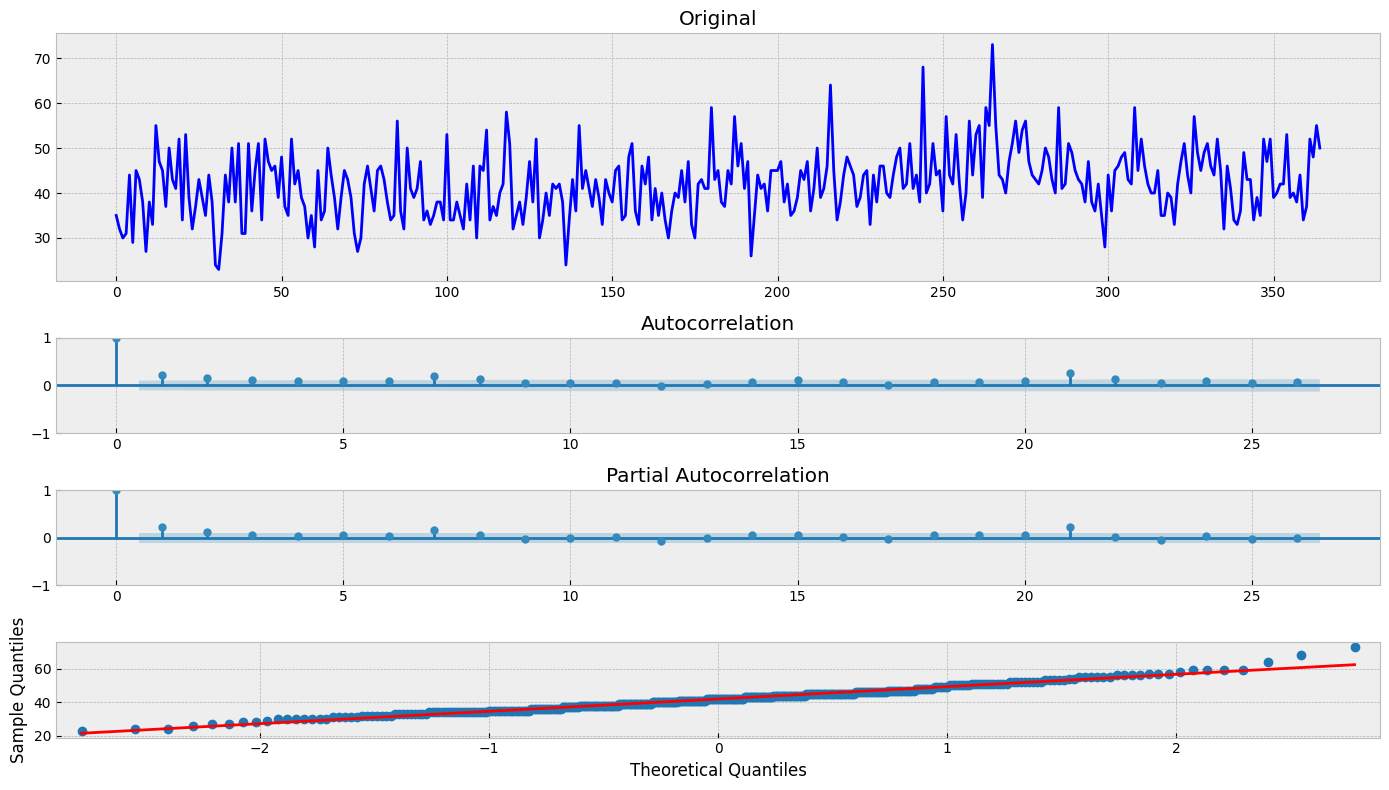

In [5]:
tsplot(series)

Успешно: order=(0, 0, 0), AIC=3776.98
Успешно: order=(0, 0, 1), AIC=3407.16
Успешно: order=(0, 1, 0), AIC=2648.77
Успешно: order=(0, 1, 1), AIC=2462.22
Всего успешных подгонок: 4
aic: 2462.22092 | order: (0, 1, 1)
Results of Dickey-Fuller Test:
Test Statistic                -1.785957e+01
p-value                        3.057045e-30
#Lags Used                     0.000000e+00
Number of Observations Used    3.640000e+02
Critical Value (1%)           -3.448443e+00
Critical Value (5%)           -2.869513e+00
Critical Value (10%)          -2.571018e+00
dtype: float64


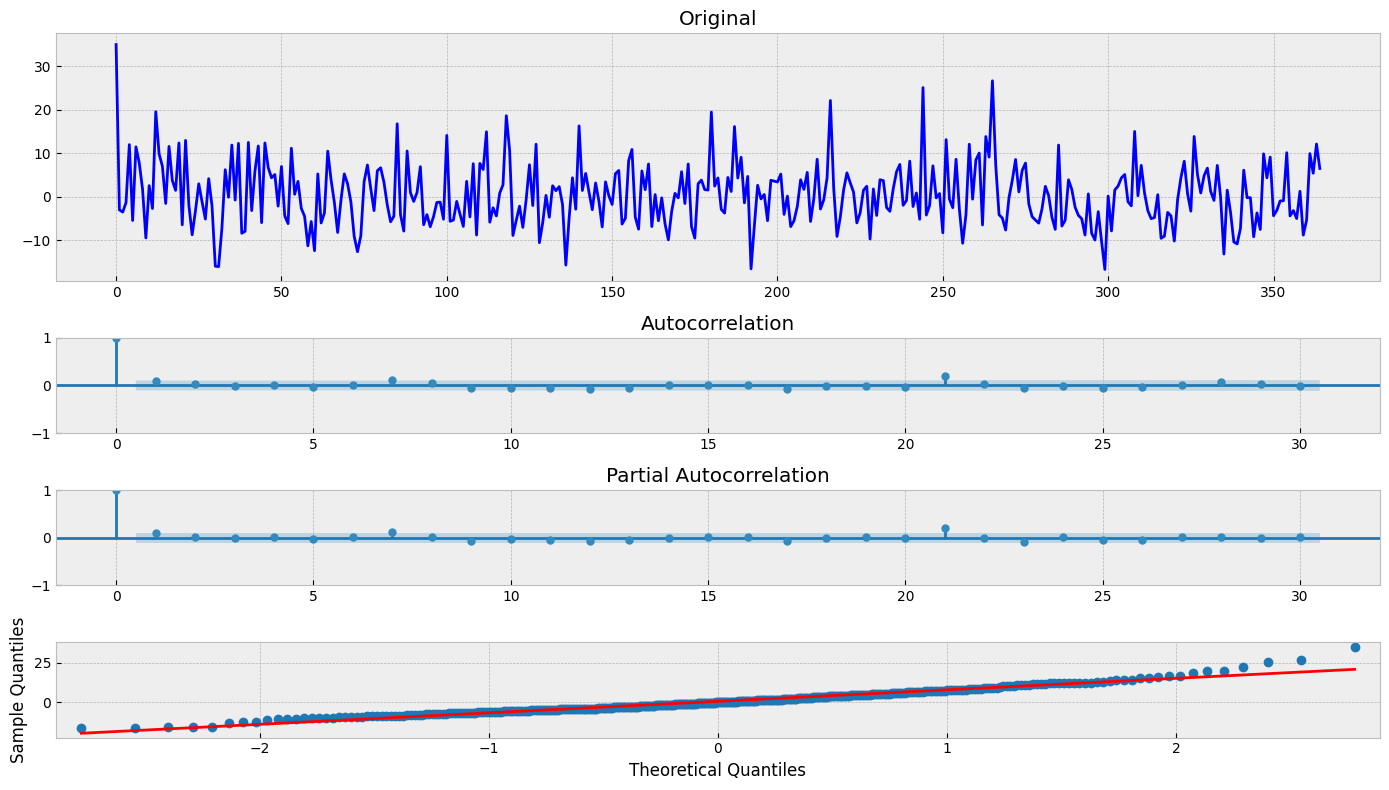

In [12]:
best_aic = np.inf 
best_order = None
best_mdl = None
successful_fits = 0

for i in range(1):
    for d in range(2):
        for j in range(2):
            try:
                tmp_mdl = ARIMA(series, order=(i, d, j), trend='n').fit()
                tmp_aic = tmp_mdl.aic
                successful_fits += 1
                print(f"Успешно: order={(i,d,j)}, AIC={tmp_aic:.2f}")
                if tmp_aic < best_aic:
                    best_aic = tmp_aic
                    best_order = (i, d, j)
                    best_mdl = tmp_mdl
            except Exception as e:
                print(f"Ошибка для order={(i,d,j)}: {e}")
                continue

print(f"Всего успешных подгонок: {successful_fits}")

if best_mdl is None:
    print("Не удалось подобрать ни одной модели!")
else:
    print('aic: {:6.5f} | order: {}'.format(best_aic, best_order))
    tsplot(best_mdl.resid, lags=30)

In [19]:
# Now we can fit the arch model using the best fit arima model parameters
p_ = 0
o_ = 1
q_ = 1

# Using student T distribution usually provides better fit
am = arch_model(series, p=p_, o=o_, q=q_, dist='StudentsT')
res = am.fit(update_freq=5)
print(res.summary())

Iteration:      5,   Func. Count:     37,   Neg. LLF: 1243.1836170200008
Iteration:     10,   Func. Count:     67,   Neg. LLF: 1243.1381793163694
Iteration:     15,   Func. Count:     97,   Neg. LLF: 1242.7013664796812
Iteration:     20,   Func. Count:    128,   Neg. LLF: 1242.425942963605
Iteration:     25,   Func. Count:    159,   Neg. LLF: 1242.2187136646053
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1242.2186262093524
            Iterations: 29
            Function evaluations: 182
            Gradient evaluations: 29
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -1242.22
Distribution:      Standardized Student's t   AIC:                           2494.44


## Выводы:
Модель GARCH не подходит для этого ряда, так как beta[1]=0.0000 и p=1.000 говорит о том, что отсутствует GARCH эффект, параметры валатильности незначительны, а gamma[1] мала, что значит нет ассиметрии.